In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import os 
from pathlib import Path
import matplotlib.pyplot as plt 
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import plotly.io as pio
pio.renderers.default = "png"


working_d = Path.cwd().parent
data_d = os.path.join(working_d, 'data')

## EDA

### 1. Read all the datasets needed for the research questions
- master.csv
- master_monthly.csv

In [2]:
master = pd.read_csv(f"{data_d}\master.csv")
master_monthly = pd.read_csv(f"{data_d}\master_monthly.csv")


In [5]:
master_monthly.dropna(inplace=True)
master_monthly['date'] = pd.to_datetime(master_monthly[['year', 'month']].assign(day=1))

### 2. EDA on master.csv data
- Plot total articles for top 20 and last 20 countries using horizontal bar chart, colored by region_group
- Choropleth world map of total articles per country; 
- Section placement breakdown (world vs. politics vs. opinion)

#### 2.1 total articles for top 20 and last 20 countries using horizontal bar chart

C:\Users\harry\AppData\Local\Temp\ipykernel_26244\4222148151.py:11: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



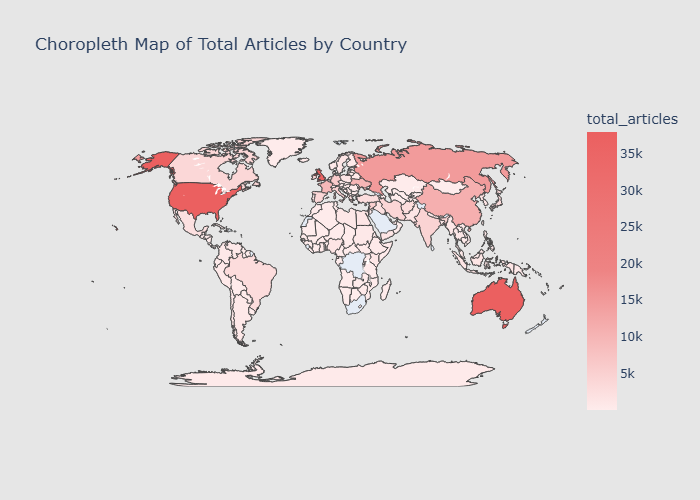

In [8]:
# Choropleth world map of total articles per country (country-unique master)
country_map = (
    master[["country", "total_articles"]]
    .dropna(subset=["country", "total_articles"])
)
light_red_scale = [
    [0.0, "#feecec"],
    [0.5, "#ee8484"],
    [1.0, "#eb6060"],
]
fig = px.choropleth(
    country_map,
    locations="country",
    locationmode="country names",
    color="total_articles",
    hover_name="country",
    color_continuous_scale=light_red_scale,
    title="Choropleth Map of Total Articles by Country",
)
fig.update_layout(
    paper_bgcolor="#e6e6e6",
    plot_bgcolor="#e6e6e6",
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type="natural earth",
        bgcolor="#e6e6e6",
    ),
)
fig.show()

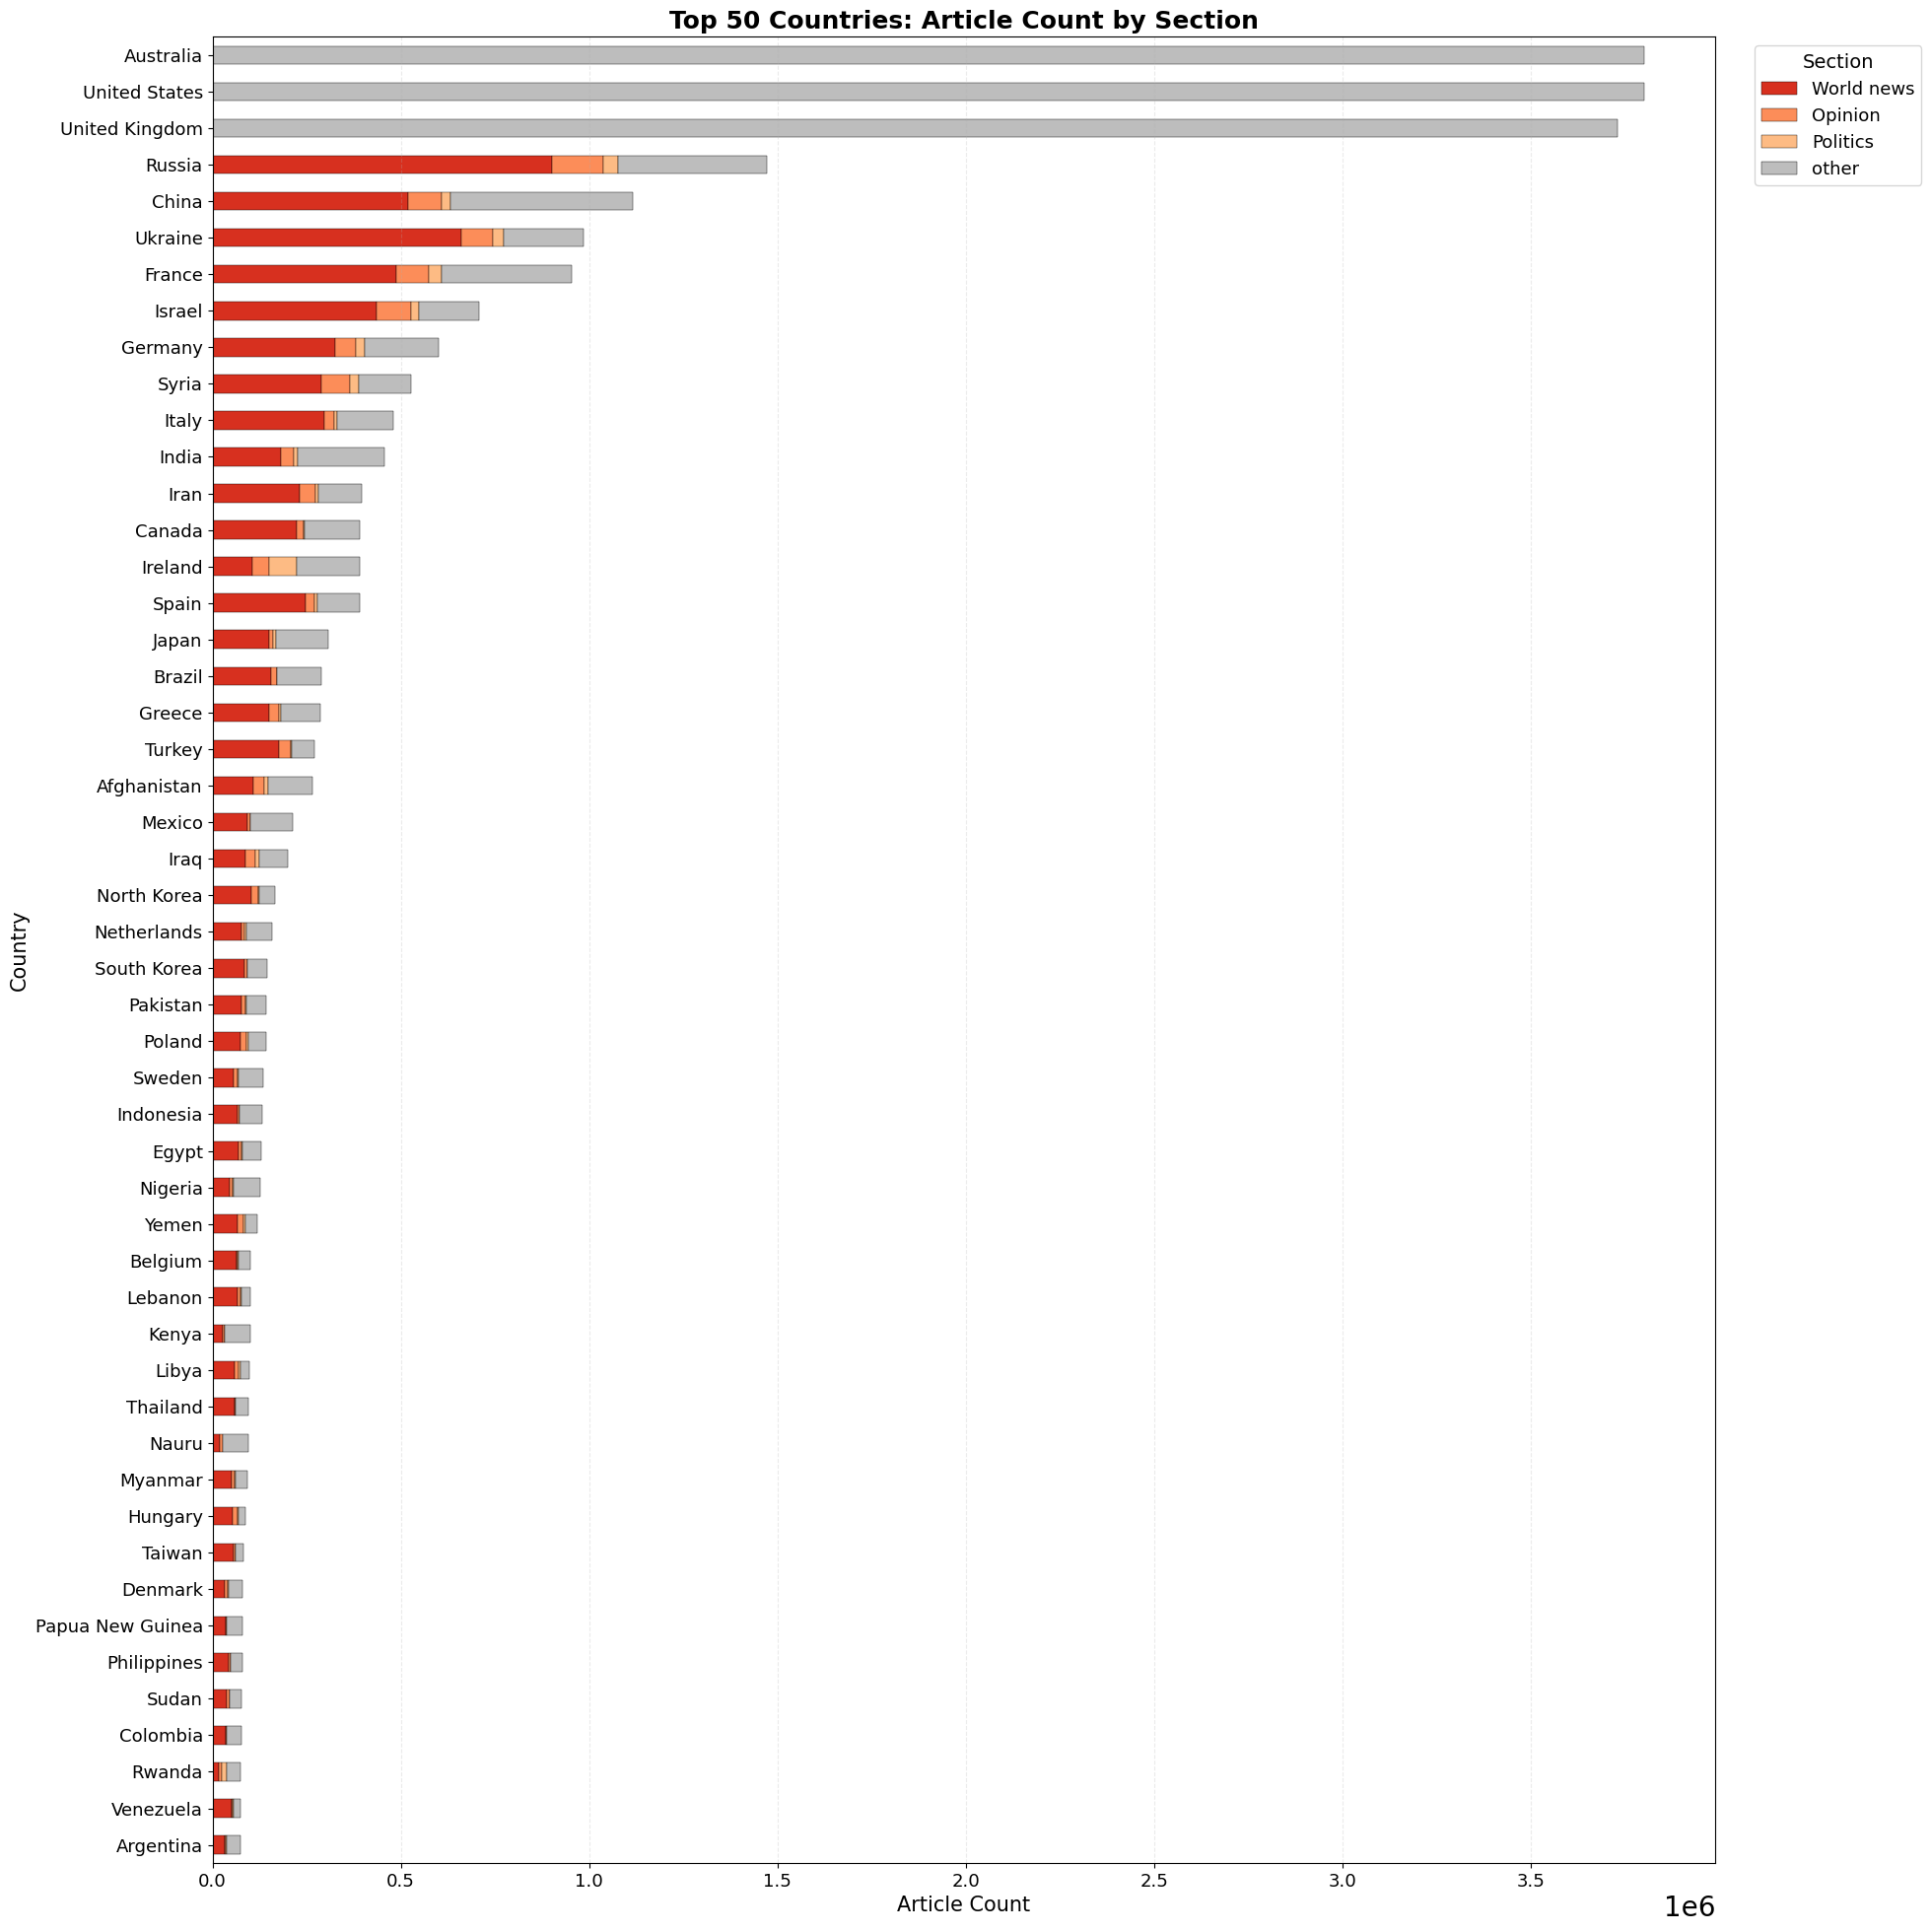

In [ ]:
cols = list(master.columns)
section_cols = cols[cols.index("Animals farmed") : cols.index("World news") + 1]
master_section_count = master.copy()
master_section_count["other"] = 0
for c in section_cols:
    if c in ["World news", "Opinion", "Politics"]:
        master_section_count[c] = master_section_count[c].fillna(0) * master_section_count["total_articles"]
    else:
        master_section_count["other"] += master_section_count[c].fillna(0)
master_section_count["other"] = master_section_count["other"] * master_section_count["total_articles"]
plt.rcParams.update({'font.size': 20})
plot_cols = ["World news", "Opinion", "Politics", "other"]
top50_sections = (master_section_count.sort_values("total_articles", ascending=False).head(50).sort_values("total_articles", ascending=True))

plot_df = top50_sections.set_index("country")[plot_cols].fillna(0)

ax = plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(20, 20),
    color=["#d7301f", "#fc8d59", "#fdbb84", "#bdbdbd"],
    edgecolor="black",
    linewidth=0.3,
)

ax.set_title("Top 50 Countries: Article Count by Section", fontsize=18, fontweight='bold')
ax.set_xlabel("Article Count", fontsize=15)
ax.set_ylabel("Country", fontsize=15)
ax.tick_params(axis='both', labelsize=13)  # y-axis country names + x-axis numbers
ax.legend(title="Section", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=13, title_fontsize=14)
ax.grid(axis="x", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

We can see that UK, US, and Australia are outliers since they are the countries where Guardian belongs to. Therefore, for the sake of the analysis, we remove them

In [11]:
master = master[~master['country'].isin(['Australia', 'United States', 'United Kingdom'])]
master_monthly = master_monthly[~master_monthly['country'].isin(['Australia', 'United States', 'United Kingdom'])]

### 3. EDA on master_monthly data
    - A dual y-axis line plot of fatalities and article count each month, colored by country
    - Distribution of fatalities, scatter plot

#### 3.1 Dual y-axis line plots of fatalities and article count each month
- Top 10 countries in terms of fatalities
- Top 10 countries in terms of article counts

In [12]:
top_10_fatalities_df = master.iloc[master['total_fatalities'].nlargest(10).index].reset_index(drop=True)
top_10_fatalities_country = master.nlargest(10, 'total_fatalities').country.tolist()
top_10_articles_df = master.iloc[master['total_articles'].nlargest(10).index].reset_index(drop=True)
top_10_articles_country = master.nlargest(10, 'total_articles').country.tolist()

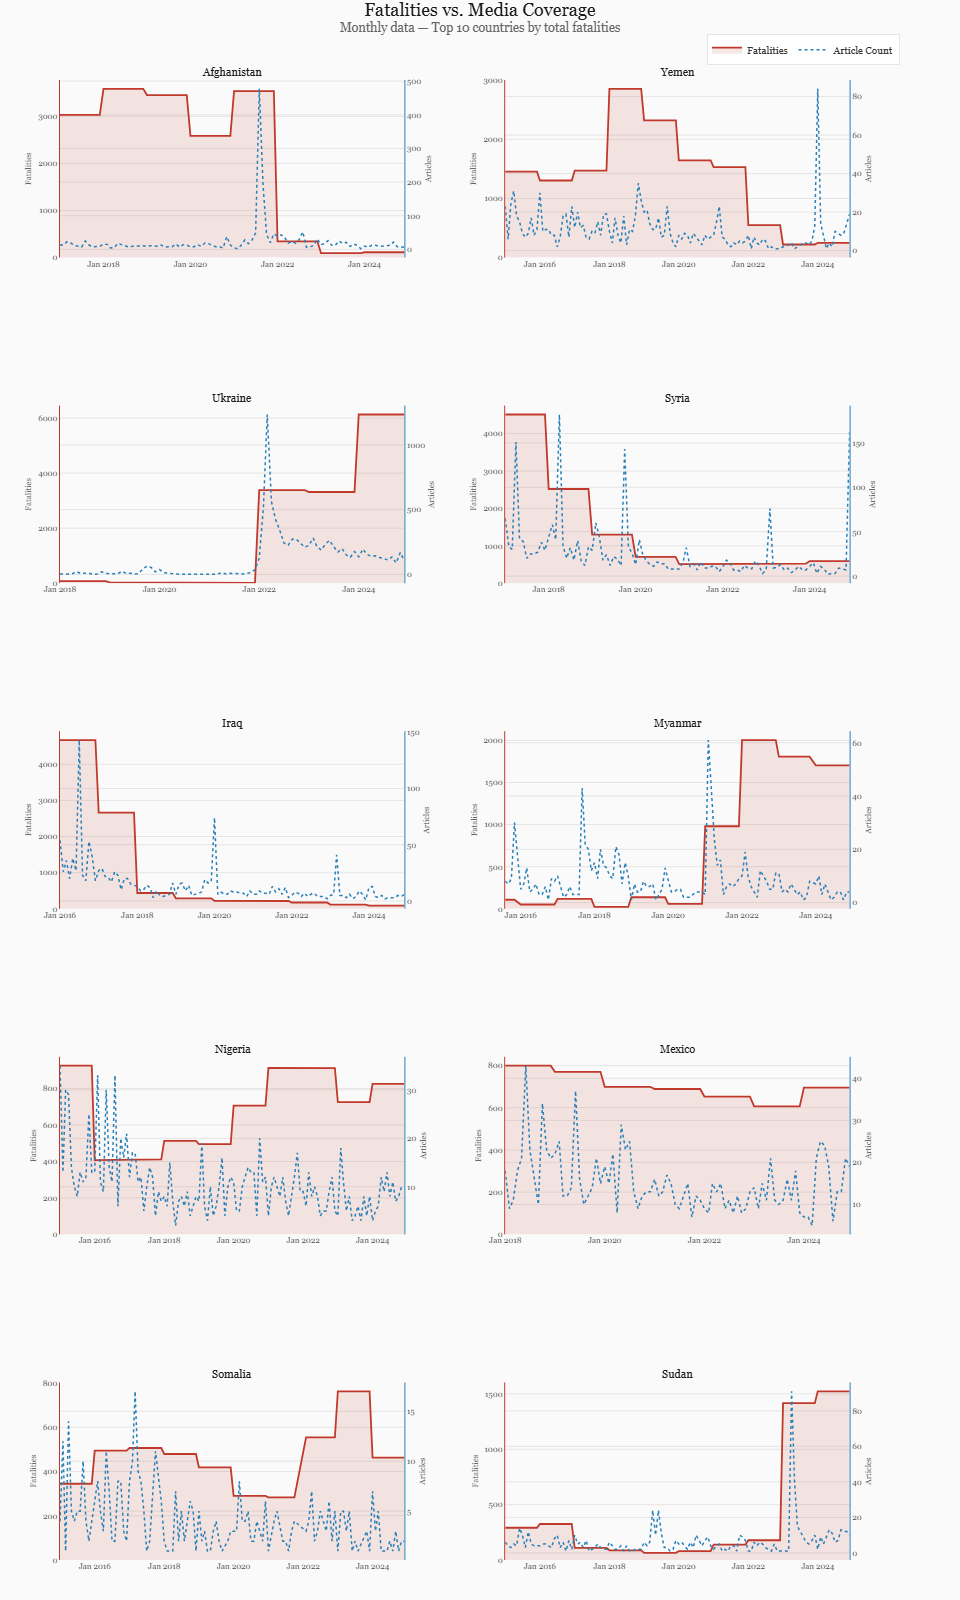

In [13]:
# ── Colour palette ──────────────────────────────────────────────────────────
FATALITY_COLOR  = "#C0392B"   
ARTICLE_COLOR   = "#2980B9"   
BG_COLOR        = "#FAFAFA"
GRID_COLOR      = "#E5E5E5"
FONT_FAMILY     = "Georgia, 'Times New Roman', serif"
TITLE_FONT      = "Georgia, serif"

fig1 = make_subplots(
    rows=5, cols=2,
    subplot_titles=top_10_fatalities_country,
    specs=[[{"secondary_y": True}] * 2] * 5,
    vertical_spacing=0.10,
    horizontal_spacing=0.12,
)

for i, c in enumerate(top_10_fatalities_country):
    row = (i // 2) + 1
    col = (i % 2) + 1
    df_c = master_monthly[master_monthly['country'] == c]

    fig1.add_trace(
        go.Scatter(
            x=df_c['date'],
            y=df_c['monthly_fatalities'],
            name="Fatalities",
            legendgroup="fatalities",
            showlegend=(i == 0),          
            mode="lines",
            line=dict(color=FATALITY_COLOR, width=1.8),
            fill="tozeroy",
            fillcolor="rgba(192,57,43,0.12)",
        ),
        row=row, col=col, secondary_y=False,
    )

    fig1.add_trace(
        go.Scatter(
            x=df_c['date'],
            y=df_c['article_count'],
            name="Article Count",
            legendgroup="articles",
            showlegend=(i == 0),
            mode="lines",
            line=dict(color=ARTICLE_COLOR, width=1.5, dash="dot"),
        ),
        row=row, col=col, secondary_y=True,
    )

    axis_kwargs = dict(
        showgrid=True,
        gridcolor=GRID_COLOR,
        gridwidth=1,
        zeroline=False,
        tickfont=dict(size=8, color="#555555", family=FONT_FAMILY),
        title_font=dict(size=8, color="#555555", family=FONT_FAMILY),
    )
    fig1.update_yaxes(
        title_text="Fatalities",
        title_standoff=4,
        linecolor=FATALITY_COLOR,
        **axis_kwargs,
        secondary_y=False,
        row=row, col=col,
    )
    fig1.update_yaxes(
        title_text="Articles",
        title_standoff=4,
        linecolor=ARTICLE_COLOR,
        **axis_kwargs,
        secondary_y=True,
        row=row, col=col,
    )
    fig1.update_xaxes(
        showgrid=False,
        tickfont=dict(size=8, color="#555555", family=FONT_FAMILY),
        tickformat="%b %Y",
        nticks=5,
        row=row, col=col,
    )


for annotation in fig1.layout.annotations:
    annotation.update(
        font=dict(size=11, family=TITLE_FONT, color="#1A1A1A"),
        x=annotation.x,
        xanchor="center",
    )

fig1.update_layout(
    height=1600,
    width=960,
    title=dict(
        text=(
            "Fatalities vs. Media Coverage"
            "<br><sup style='color:#666'>Monthly data — Top 10 countries by total fatalities</sup>"
        ),
        font=dict(size=18, family=TITLE_FONT, color="#1A1A1A"),
        x=0.5,
        xanchor="center",
        y=0.99,
    ),
    paper_bgcolor=BG_COLOR,
    plot_bgcolor=BG_COLOR,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.01,
        xanchor="right",
        x=1,
        font=dict(size=10, family=FONT_FAMILY, color="#333333"),
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor=GRID_COLOR,
        borderwidth=1,
    ),
    margin=dict(t=80, b=40, l=60, r=60),
    hovermode="x unified",
)

fig1.show()

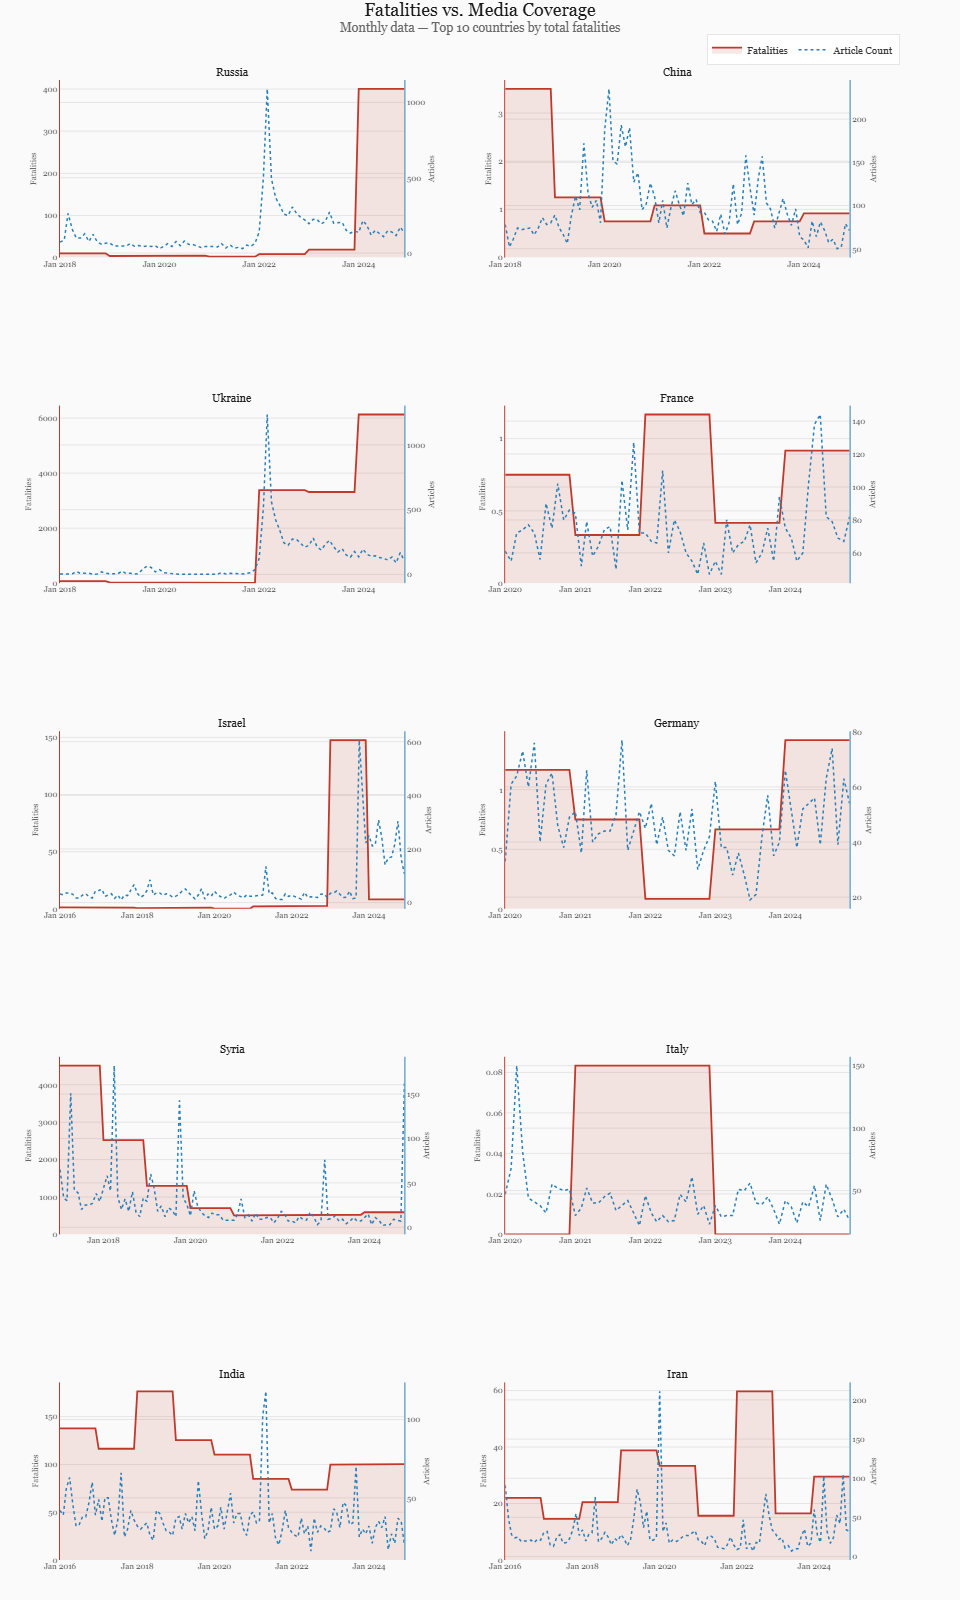

In [14]:
fig2 = make_subplots(
    rows=5, cols=2,
    subplot_titles=top_10_articles_country,
    specs=[[{"secondary_y": True}] * 2] * 5,
    vertical_spacing=0.10,
    horizontal_spacing=0.12,
)

for i, c in enumerate(top_10_articles_country):
    row = (i // 2) + 1
    col = (i % 2) + 1
    df_c = master_monthly[master_monthly['country'] == c]

    fig2.add_trace(
        go.Scatter(
            x=df_c['date'],
            y=df_c['monthly_fatalities'],
            name="Fatalities",
            legendgroup="fatalities",
            showlegend=(i == 0),          
            mode="lines",
            line=dict(color=FATALITY_COLOR, width=1.8),
            fill="tozeroy",
            fillcolor="rgba(192,57,43,0.12)",
        ),
        row=row, col=col, secondary_y=False,
    )

    fig2.add_trace(
        go.Scatter(
            x=df_c['date'],
            y=df_c['article_count'],
            name="Article Count",
            legendgroup="articles",
            showlegend=(i == 0),
            mode="lines",
            line=dict(color=ARTICLE_COLOR, width=1.5, dash="dot"),
        ),
        row=row, col=col, secondary_y=True,
    )

    axis_kwargs = dict(
        showgrid=True,
        gridcolor=GRID_COLOR,
        gridwidth=1,
        zeroline=False,
        tickfont=dict(size=8, color="#555555", family=FONT_FAMILY),
        title_font=dict(size=8, color="#555555", family=FONT_FAMILY),
    )
    fig2.update_yaxes(
        title_text="Fatalities",
        title_standoff=4,
        linecolor=FATALITY_COLOR,
        **axis_kwargs,
        secondary_y=False,
        row=row, col=col,
    )
    fig2.update_yaxes(
        title_text="Articles",
        title_standoff=4,
        linecolor=ARTICLE_COLOR,
        **axis_kwargs,
        secondary_y=True,
        row=row, col=col,
    )
    fig2.update_xaxes(
        showgrid=False,
        tickfont=dict(size=8, color="#555555", family=FONT_FAMILY),
        tickformat="%b %Y",
        nticks=5,
        row=row, col=col,
    )


for annotation in fig2.layout.annotations:
    annotation.update(
        font=dict(size=11, family=TITLE_FONT, color="#1A1A1A"),
        x=annotation.x,
        xanchor="center",
    )

fig2.update_layout(
    height=1600,
    width=960,
    title=dict(
        text=(
            "Fatalities vs. Media Coverage"
            "<br><sup style='color:#666'>Monthly data — Top 10 countries by total fatalities</sup>"
        ),
        font=dict(size=18, family=TITLE_FONT, color="#1A1A1A"),
        x=0.5,
        xanchor="center",
        y=0.99,
    ),
    paper_bgcolor=BG_COLOR,
    plot_bgcolor=BG_COLOR,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.01,
        xanchor="right",
        x=1,
        font=dict(size=10, family=FONT_FAMILY, color="#333333"),
        bgcolor="rgba(255,255,255,0.85)",
        bordercolor=GRID_COLOR,
        borderwidth=1,
    ),
    margin=dict(t=80, b=40, l=60, r=60),
    hovermode="x unified",
)

fig2.show()

#### 3.2 The distribution of fatalities for countries with top 10 fatalities

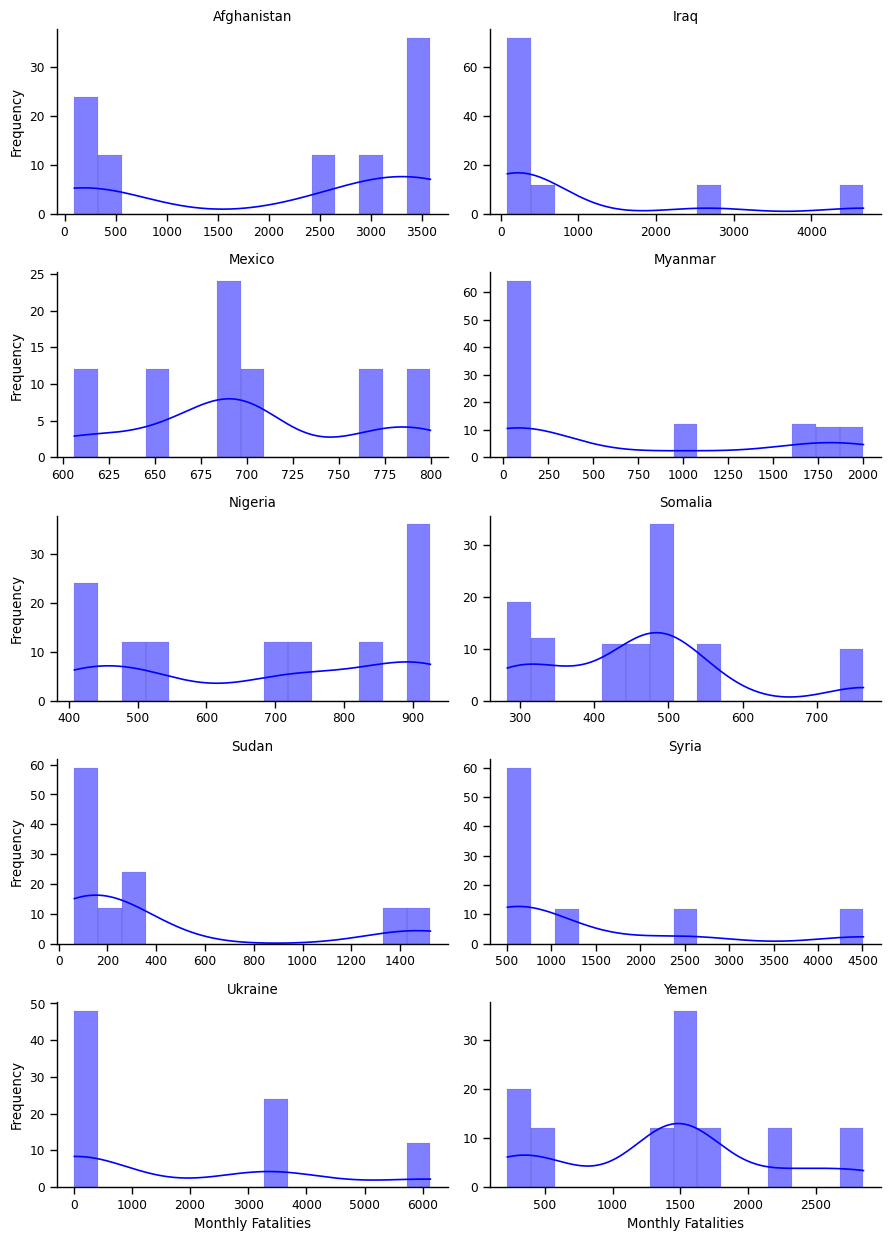

In [86]:
top_10_fatalities_df = master_monthly[master_monthly['country'].isin(top_10_fatalities_country)]
sns.set_context("paper", font_scale=1.0)
g = sns.displot(
    data=top_10_fatalities_df, 
    x="monthly_fatalities", 
    col="country", 
    col_wrap=2,  
    kind="hist", 
    kde=True,
    facet_kws={'sharex': False, 'sharey': False}, 
    common_bins=False, 
    bins=15, 
    height=2.5, 
    aspect=1.8, 
    color="blue",
    edgecolor="black"
)


g.set_titles("{col_name}")
g.set_axis_labels("Monthly Fatalities", "Frequency")

plt.show()

#### 3.3 The distribution of word count for countries with top 10 fatalities

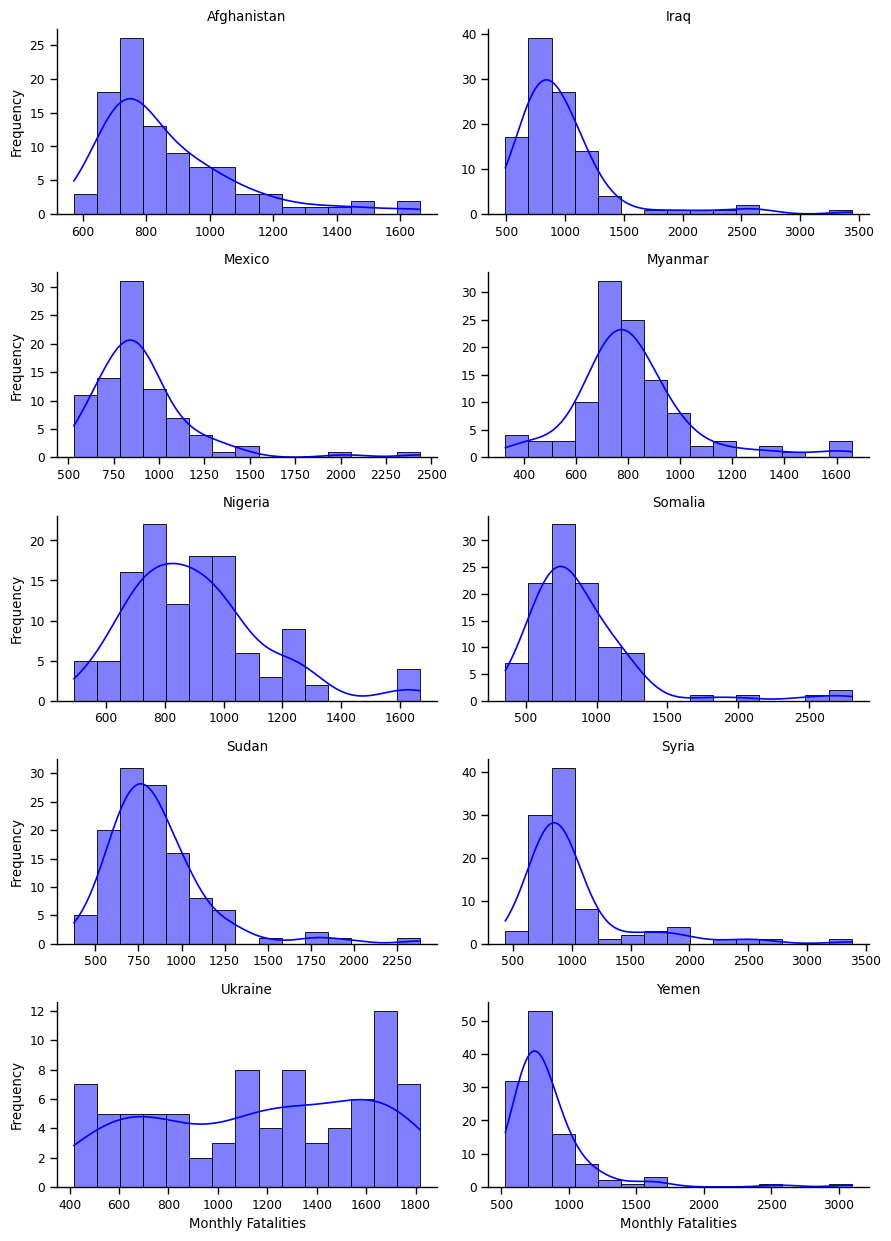

In [87]:
sns.set_context("paper", font_scale=1.0)
g = sns.displot(
    data=top_10_fatalities_df, 
    x="avg_wordcount", 
    col="country", 
    col_wrap=2,  
    kind="hist", 
    kde=True,
    facet_kws={'sharex': False, 'sharey': False}, 
    common_bins=False, 
    bins=15, 
    height=2.5, 
    aspect=1.8, 
    color="blue",
    edgecolor="black"
)

# Improve titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("Monthly Fatalities", "Frequency")

plt.show()

#### The distribution of articles for countries with top 10 article count

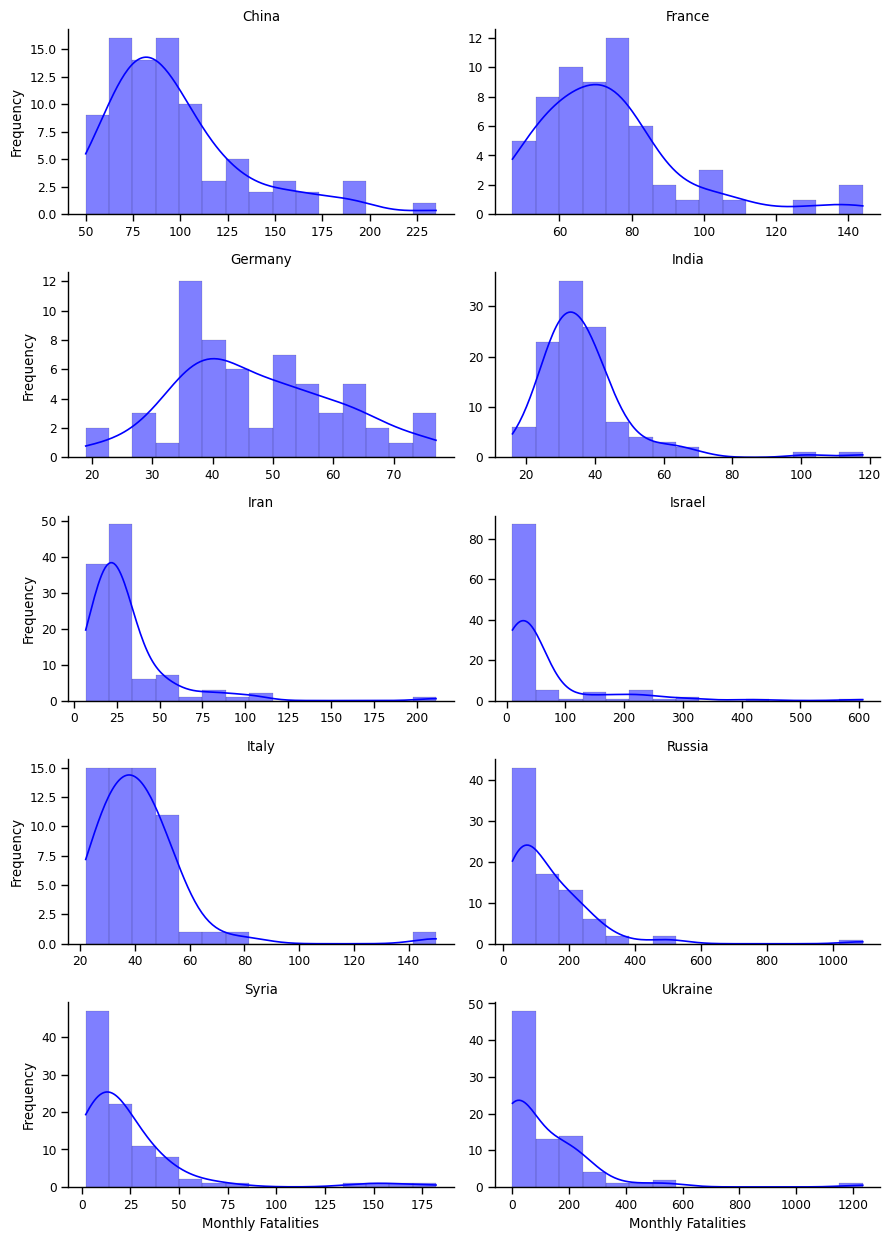

In [88]:
top_10_articles_df = master_monthly[master_monthly['country'].isin(top_10_articles_country)]
sns.set_context("paper", font_scale=1.0)
g = sns.displot(
    data=top_10_articles_df, 
    x="article_count", 
    col="country", 
    col_wrap=2,  
    kind="hist", 
    kde=True,
    facet_kws={'sharex': False, 'sharey': False}, 
    common_bins=False, 
    bins=15, 
    height=2.5, 
    aspect=1.8, 
    color="blue",
    edgecolor="black"
)

# Improve titles and labels
g.set_titles("{col_name}")
g.set_axis_labels("Monthly Fatalities", "Frequency")

plt.show()

#### 3.3 Total Number of Articles per Month for Global South & Wester

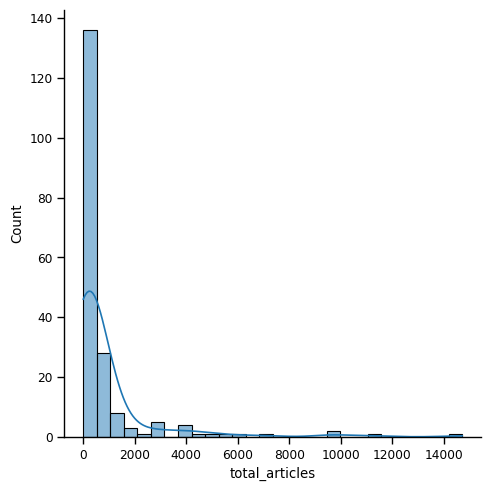

In [89]:
sns.displot(master['total_articles'], kde=True)

<Axes: xlabel='date', ylabel='article_count'>

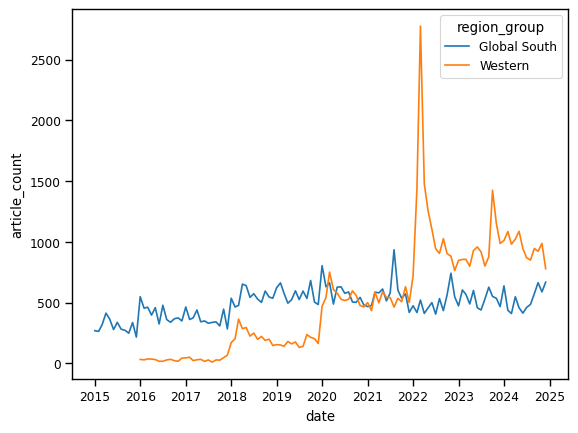

In [90]:
total_fatalities_group = master_monthly.groupby(['region_group', 'date'])['article_count'].sum().reset_index()
sns.lineplot(total_fatalities_group, x='date', y='article_count', hue='region_group')

---
## Research Question 1
**Is there a measurable disparity in Guardian coverage volume between Global South and Western countries, controlling for conflict severity?** <br>
Countries with zero fatalities in ACLED are excluded from this specific analysis, as the ratio is undefined.

### Steps 
1. Remove countries with 0 fatalities, log_transform total_articles and articles_per_1000_fatalities to ensure ANOVA normality assumptions 

    Scatter plot —  log(fatalities) on the x-axis against log(article count) on the y-axis, colouring points by `region_group` (Global South vs. Western).


2. Segment data according to fatality bins [0, 10, 100, 1000, 10000, float('inf')]<br>
    Box plot - of log_total_articles faceted by bin and coloured by region. 

3. Two-way ANOVA with $Factor A = region group$, $Factor B = severity\:bin$, and $Dependent Variable = log(total_articles)$
### ANOVA 


**Assumptions:**
- Normality of residuals — use the Shapiro-Wilk test and a Q-Q plot on model residuals. With log-transformation this should be approximately satisfied.
- Homoscedasticity — use Levene's test across the region × bin groups. If this fails, switch to Welch's ANOVA (which doesn't assume equal variances) using pingouin.welch_anova or run the analysis with robust standard errors.
- Independence — countries are independent observations.

**Reporting:** F-statistic, degrees of freedom, p-value, and effect size (η²). A significant p-value (<0.05) combined with a meaningful η² (>0.06 = medium) provides evidence of a systematic disparity.

### Step 1 — Data Preparation & Scatter plot: article count vs. fatalities by region

In [91]:
master["log_fatalities"] = np.log1p(master["total_fatalities"])
master["log_articles"]   = np.log1p(master["total_articles"])

In [92]:
# Exclude countries with zero fatalities (log of 0 is undefined)
scatter_df = master[master["total_fatalities"] > 0].copy()

color_map = {"Global South": "#e05c5c", "Western": "#4c7bb5"}

fig = px.scatter(
    scatter_df,
    x="log_fatalities",
    y="log_articles",
    color="region_group",
    color_discrete_map=color_map,
    hover_name="country",
    hover_data={
        "total_articles": True,
        "total_fatalities": True,
        "log_fatalities": False,
        "log_articles": False,
        "region_group": False,
    },
    title="Guardian Article Count vs. Conflict Fatalities by Region (2015–2024)",
    labels={
        "log_fatalities": "log₁₀(Total Fatalities)",
        "log_articles":   "log₁₀(Total Articles)",
        "region_group":   "Region",
    },
)

# Add a separate OLS trendline per region group to show divergence
for group, color in color_map.items():
    grp = scatter_df[scatter_df["region_group"] == group]
    m, b = np.polyfit(grp["log_fatalities"], grp["log_articles"], 1)
    x_range = np.linspace(grp["log_fatalities"].min(), grp["log_fatalities"].max(), 100)
    fig.add_scatter(
        x=x_range,
        y=m * x_range + b,
        mode="lines",
        line=dict(color=color, dash="dash", width=1.5),
        showlegend=False,
        hoverinfo="skip",
    )

fig.update_traces(marker=dict(size=8, opacity=0.8, line=dict(width=0.5, color="black")),
                  selector=dict(mode="markers"))
fig.update_layout(
    width=900,
    height=600,
    legend=dict(title="Region", x=0.01, y=0.99),
    xaxis=dict(showgrid=True, gridcolor="#e0e0e0"),
    yaxis=dict(showgrid=True, gridcolor="#e0e0e0"),
    plot_bgcolor="white",
)
fig.show()

print(scatter_df.groupby("region_group")[["total_articles", "total_fatalities",
                                          "articles_per_1000_fatalities"]].median().round(1))

              total_articles  total_fatalities  articles_per_1000_fatalities
region_group                                                                
Global South           225.0             296.5                         597.8
Western                424.0               3.0                      100916.7


#### Comment: 
1. We can see that the despite lower fatalities, western countries get more coverage overall, as shown by the fitted line.
2. Global south countries lie at the lower half the the region

### Step 2. Matched comparison: countries with similar fatalities, different regions

In [93]:
match_df = master[master["total_fatalities"] > 0].copy()
bin_edges  = [1, 10, 100, 1_000, 10_000, float("inf")]
bin_labels = ["1–9", "10–99", "100–999", "1k–10k", "10k+"]
match_df["severity_bin"] = pd.cut(
    match_df["total_fatalities"],
    bins=bin_edges,
    labels=bin_labels,
    right=False,
)

match_df.groupby(['region_group','severity_bin'])['total_fatalities'].sum().reset_index()

C:\Users\harry\AppData\Local\Temp\ipykernel_9272\121752042.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,region_group,severity_bin,total_fatalities
0,Global South,1–9,55
1,Global South,10–99,742
2,Global South,100–999,10311
3,Global South,1k–10k,110366
4,Global South,10k+,1219652
5,Western,1–9,86
6,Western,10–99,255
7,Western,100–999,216
8,Western,1k–10k,9070
9,Western,10k+,155454


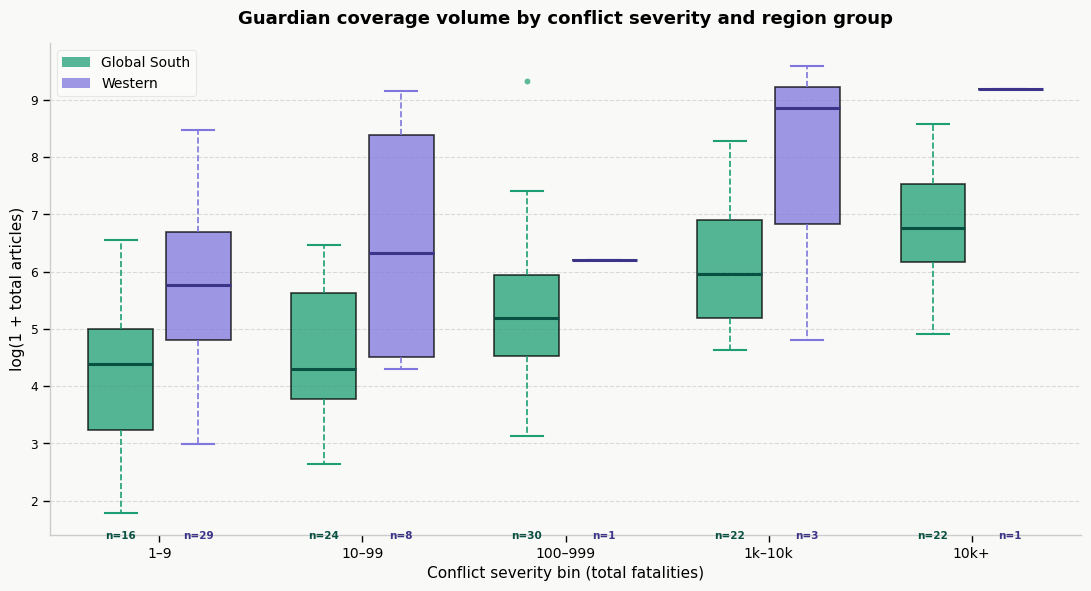

In [94]:
import matplotlib
import matplotlib.patches as mpatches
%matplotlib inline

def styled_box(ax, data, positions, color, medcolor, label):
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=width,
        patch_artist=True,
        notch=False,
        showfliers=True,
        boxprops=dict(facecolor=color, alpha=0.75, linewidth=1.2),
        medianprops=dict(color=medcolor, linewidth=2.2),
        whiskerprops=dict(color=color, linewidth=1.2, linestyle='--'),
        capprops=dict(color=color, linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor=color, markeredgecolor='white',
                        markersize=5, alpha=0.7, linewidth=0.5),
        manage_ticks=False,
        label=label
    )
    return bp

cols = {'Global South': '#1D9E75', 'Western': '#7F77DD'}
medline = {'Global South': '#085041', 'Western': '#3C3489'}

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F9F9F7')
ax.set_facecolor('#F9F9F7')

n_bins = len(bin_labels)
width = 0.32
gap = 0.06
positions_gs = np.arange(n_bins)
positions_w  = np.arange(n_bins) + width + gap

all_data_gs, all_data_w = [], []
for bl in bin_labels:
    gs = match_df[(match_df['severity_bin']==bl) & (match_df['region_group']=='Global South')]['log_articles'].values
    w  = match_df[(match_df['severity_bin']==bl) & (match_df['region_group']=='Western')]['log_articles'].values
    all_data_gs.append(gs)
    all_data_w.append(w)


styled_box(ax, all_data_gs, positions_gs, cols['Global South'], medline['Global South'], 'Global South')
styled_box(ax, all_data_w, positions_w, cols['Western'], medline['Western'], 'Western')

for i, (gs, w) in enumerate(zip(all_data_gs, all_data_w)):
    ax.text(positions_gs[i], 1.3, f'n={len(gs)}', ha='center', va='bottom',
            fontsize=7.5, color=medline['Global South'], fontweight='bold')
    ax.text(positions_w[i],  1.3, f'n={len(w)}',  ha='center', va='bottom',
            fontsize=7.5, color=medline['Western'],      fontweight='bold')

tick_positions = (positions_gs + positions_w) / 2
ax.set_xticks(tick_positions)
ax.set_xticklabels(bin_labels, fontsize=10)

ax.set_ylabel('log(1 + total articles)', fontsize=11)
ax.set_xlabel('Conflict severity bin (total fatalities)', fontsize=11)
ax.set_title('Guardian coverage volume by conflict severity and region group',
             fontsize=13, fontweight='bold', pad=14)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#BBBBBB')
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#CCCCCC')

patch_gs = mpatches.Patch(facecolor=cols['Global South'], alpha=0.75, label='Global South')
patch_w  = mpatches.Patch(facecolor=cols['Western'],      alpha=0.75, label='Western')
ax.legend(handles=[patch_gs, patch_w], fontsize=10, framealpha=0.4,
          loc='upper left', edgecolor='#CCCCCC')

ax.set_xlim(-0.35, n_bins - 1 + width + gap + 0.35)

plt.tight_layout()
#plt.savefig('coverage_boxplot.png', dpi=160, bbox_inches='tight')
plt.show()

Comment: 
- We have confirmed from box plot that for all fatality bins, the Western box sits very high.
- However, the western country data points are too small (eg.9,2,3,1), which do not form meaningful boxes
- Given this

### Step 3 ANOVA
- Check assumptions
    - Normality of residuals
    - Equal Variance

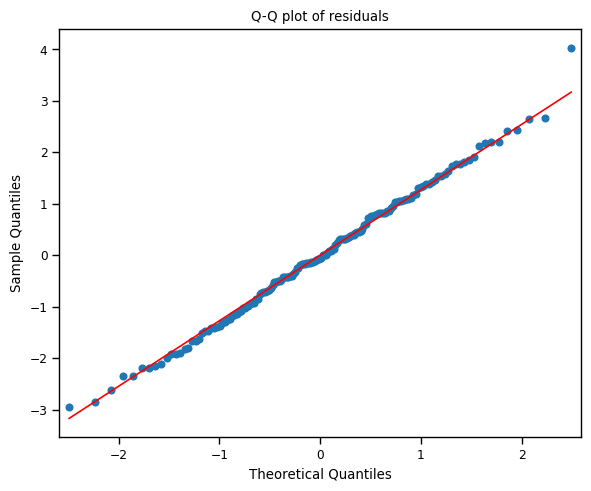

In [95]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import qqplot
from scipy.stats import levene

model = smf.ols('log_articles ~ C(region_group) * C(severity_bin)', data=match_df).fit()
residuals = model.resid
fig, ax = plt.subplots(figsize=(6, 5))
sm.qqplot(residuals, line='s', ax=ax)
ax.set_title('Q-Q plot of residuals')
plt.tight_layout()
plt.show()

In [96]:
levene_test_data = []
for bl in bin_labels:
    for r in match_df['region_group'].unique().tolist():
        levene_test_data.append(match_df.loc[(match_df['severity_bin']==bl) & 
                                             (match_df['region_group']==r),
                                             'log_articles'])

In [97]:
levene(*levene_test_data)

LeveneResult(statistic=np.float64(2.4852328497914757), pvalue=np.float64(0.011379926869487427))

#### We swtich to OLS regression 

In [98]:
model = smf.ols('log_articles ~ C(region_group) * C(severity_bin)', data=match_df).fit(cov_type='HC3')
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(region_group),36.195530,1.0,20.950304,1.000275e-05
C(severity_bin),128.830272,4.0,18.642035,2.131665e-12
C(region_group):C(severity_bin),0.146810,4.0,0.021244,9.991112e-01
Residual,252.242034,146.0,NaN,NaN


C:\Users\harry\AppData\Local\Temp\ipykernel_9272\1918071737.py:19: SmallSampleWarning:

One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.



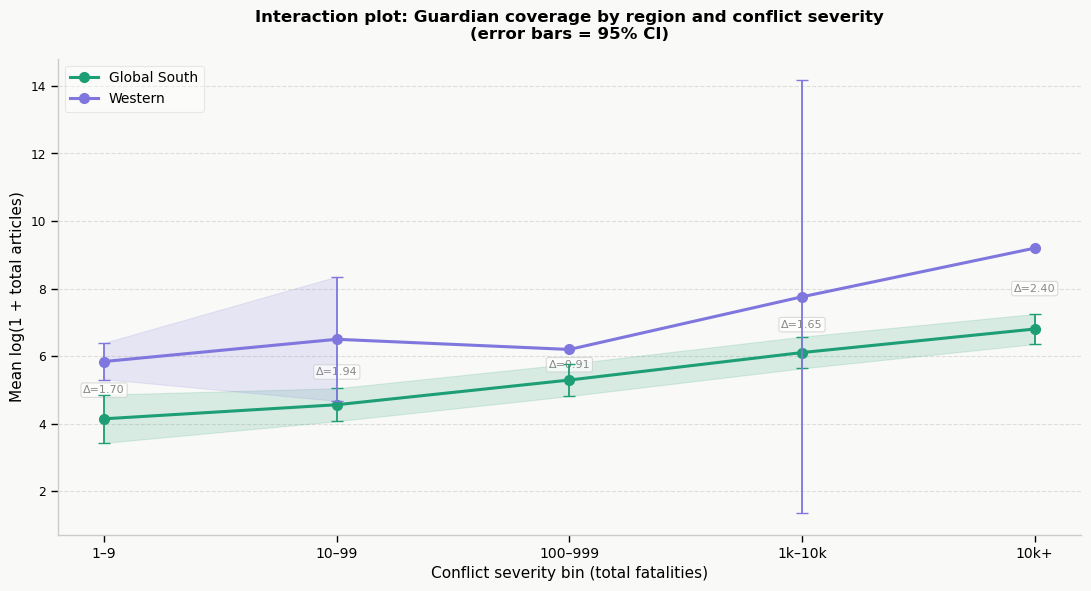

In [99]:
col = {'Global South': '#1D9E75', 'Western': '#7F77DD'}

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F9F9F7')
ax.set_facecolor('#F9F9F7')

x = np.arange(len(bin_labels))

for region in ['Global South', 'Western']:
    means, cis = [], []
    for bl in bin_labels:
        vals = match_df[
            (match_df['severity_bin'] == bl) &
            (match_df['region_group'] == region)
        ]['log_articles'].values

        n    = len(vals)
        mean = vals.mean()
        se   = stats.sem(vals)
        ci   = se * stats.t.ppf(0.975, df=n-1)

        means.append(mean)
        cis.append(ci)

    means = np.array(means)
    cis   = np.array(cis)

    ax.plot(x, means, marker='o', linewidth=2.2, markersize=7,
            color=col[region], label=region, zorder=3)

    ax.fill_between(x, means - cis, means + cis,
                    alpha=0.15, color=col[region], zorder=2)

    ax.errorbar(x, means, yerr=cis, fmt='none',
                ecolor=col[region], elinewidth=1.3, capsize=4, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(bin_labels, fontsize=10)
ax.set_ylabel('Mean log(1 + total articles)', fontsize=11)
ax.set_xlabel('Conflict severity bin (total fatalities)', fontsize=11)
ax.set_title(
    'Interaction plot: Guardian coverage by region and conflict severity\n(error bars = 95% CI)',
    fontsize=12, fontweight='bold', pad=14
)

ax.yaxis.grid(True, linestyle='--', alpha=0.45, color='#BBBBBB')
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#CCCCCC')

ax.legend(fontsize=10, framealpha=0.4, edgecolor='#CCCCCC', loc='upper left')

for i, bl in enumerate(bin_labels):
    gs_mean = match_df[
        (match_df['severity_bin'] == bl) &
        (match_df['region_group'] == 'Global South')
    ]['log_articles'].mean()

    w_mean = match_df[
        (match_df['severity_bin'] == bl) &
        (match_df['region_group'] == 'Western')
    ]['log_articles'].mean()

    gap = w_mean - gs_mean
    ax.annotate(
        f'Δ={gap:.2f}',
        xy=(i, (gs_mean + w_mean) / 2),
        ha='center', va='center', fontsize=8, color='#888888',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='#CCCCCC', alpha=0.7)
    )

plt.tight_layout()

1. There is a strong, statistically significant coverage disparity between Western and Global South countries that cannot be explained by conflict severity (region F=68.25, p≈0).
2. Conflict severity itself showed significant results (severity F=32.96, p≈0), confirming the control for severity is meaningful.
3. We fail to reject the null hypothesis that the regional coverage gap is the same across all severity bins.
    - This means it is consistent across all severity bins that coverage on Western countries is higher.

In [100]:
master

,country,total_articles,avg_wordcount,med_wordcount,total_fatalities,region_group,Animals farmed,Art and design,Australia news,Books,...,Vital Signs,Voluntary Sector Network,Weather,Wellness,Women in Leadership,Working in development,World news,articles_per_1000_fatalities,log_fatalities,log_articles
0,Afghanistan,2656,983.133660,783.0,200899,Global South,0.0,0.376506,9.375000,0.978916,...,0.000000,0.037651,0.0,0.0,0.0,0.677711,40.888554,13.220574,12.210563,7.884953
1,Albania,162,1049.043210,797.5,4,Global South,0.0,2.469136,0.000000,6.172840,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,35.802469,40500.000000,1.609438,5.093750
2,Algeria,130,846.176923,761.5,649,Global South,0.0,3.076923,0.769231,5.384615,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,51.538462,200.308166,6.476972,4.875197
3,Andorra,5,718.200000,772.0,0,Western,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,20.000000,NaN,0.000000,1.791759
4,Angola,117,900.282051,756.0,765,Global South,0.0,3.418803,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.0,0.000000,54.700855,152.941176,6.641182,4.770685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,Vietnam,442,951.400452,740.0,28,Global South,0.0,2.262443,6.561086,2.941176,...,0.000000,0.000000,0.0,0.0,0.0,0.904977,33.710407,15785.714286,3.367296,6.093570
193,Yemen,1198,972.699499,745.5,163211,Global South,0.0,0.166945,0.584307,0.166945,...,0.000000,0.000000,0.0,0.0,0.0,0.918197,55.676127,7.340192,12.002805,7.089243
194,Zambia,141,762.170213,649.0,137,Global South,0.0,0.000000,0.000000,4.255319,...,0.000000,0.000000,0.0,0.0,0.0,0.709220,29.078014,1029.197080,4.927254,4.955827
195,Zimbabwe,568,836.369718,747.5,243,Global South,0.0,0.000000,0.352113,3.169014,...,0.176056,0.000000,0.0,0.0,0.0,0.352113,47.359155,2337.448560,5.497168,6.343880


---
## Research Question 2
**Do structural features of articles — length and section placement — differ systematically by region?**

For **article length**, the question is whether Global South articles are systematically shorter than Western articles. For **section placement**, the question is whether Global South coverage concentrates in brief world-news mentions while Western stories more often appear in Opinion or Politics.

### Steps

1. **Boxplots** — Plot the distribution of `med_wordcount` by `region_group`. Median word count is more informative than mean because word count is right-skewed.

2. Use Mann-Whitney U to test whether one group systematically have higher median wordcounts.<br> 
> H₀: The distribution of med_wordcount is the same for Global South and Western countries. A randomly chosen Global South country is equally likely to have a higher or lower word count than a randomly chosen Western country.



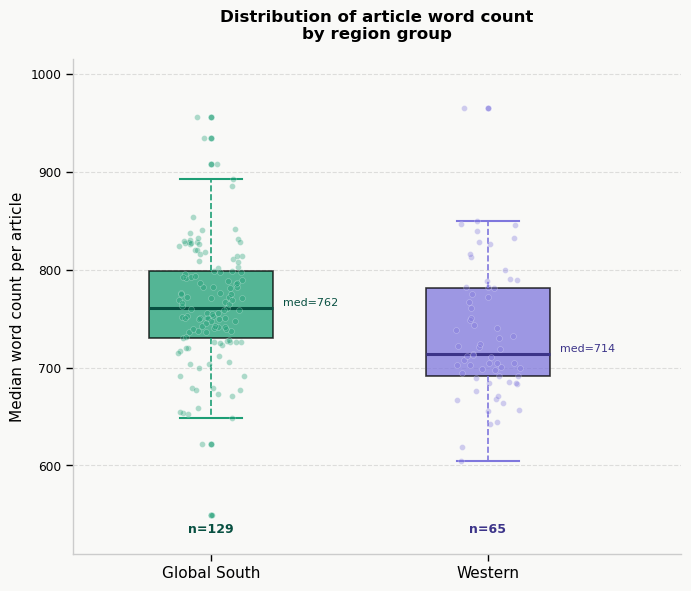

In [101]:
col     = {'Global South': '#1D9E75', 'Western': '#7F77DD'}
medline = {'Global South': '#085041', 'Western': '#3C3489'}
regions = ['Global South', 'Western']

box_df = [master[master['region_group'] == r]['med_wordcount'].dropna().values for r in regions]

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#F9F9F7')
ax.set_facecolor('#F9F9F7')

bp = ax.boxplot(
    box_df,
    positions=[1, 2],
    widths=0.45,
    patch_artist=True,
    notch=False,
    showfliers=True,
    boxprops=dict(linewidth=1.2),
    medianprops=dict(linewidth=2.2),
    whiskerprops=dict(linewidth=1.2, linestyle='--'),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markeredgecolor='white', markersize=5, alpha=0.7, linewidth=0.5),
    manage_ticks=False
)

for patch, region in zip(bp['boxes'], regions):
    patch.set_facecolor(col[region])
    patch.set_alpha(0.75)

for median, region in zip(bp['medians'], regions):
    median.set_color(medline[region])

for flier, region in zip(bp['fliers'], regions):
    flier.set_markerfacecolor(col[region])

for i, region in enumerate(regions):
    bp['whiskers'][i*2].set_color(col[region])
    bp['whiskers'][i*2 + 1].set_color(col[region])
    bp['caps'][i*2].set_color(col[region])
    bp['caps'][i*2 + 1].set_color(col[region])

# jittered individual points
np.random.seed(42)
for pos, vals, region in zip([1, 2], box_df, regions):
    jitter = np.random.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(pos + jitter, vals, alpha=0.35, s=18,
               color=col[region], edgecolors='white', linewidths=0.4, zorder=3)

# n= and median annotations
for pos, vals, region in zip([1, 2], box_df, regions):
    ax.text(pos, master['med_wordcount'].min() - 18, f'n={len(vals)}',
            ha='center', fontsize=9, color=medline[region], fontweight='bold')
    ax.text(pos + 0.26, np.median(vals) + 2, f'med={np.median(vals):.0f}',
            ha='left', fontsize=8, color=medline[region])



ax.set_xticks([1, 2])
ax.set_xticklabels(regions, fontsize=11)
ax.set_ylabel('Median word count per article', fontsize=11)
ax.set_title('Distribution of article word count\nby region group', fontsize=12, fontweight='bold', pad=14)
ax.set_xlim(0.5, 2.7)
ax.set_ylim(master['med_wordcount'].min() - 40, master['med_wordcount'].max() + 50)

ax.yaxis.grid(True, linestyle='--', alpha=0.45, color='#BBBBBB')
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#CCCCCC')

plt.tight_layout()

In [102]:
gs = master[master['region_group'] == 'Global South']['med_wordcount'].dropna().values
w  = master[master['region_group'] == 'Western']['med_wordcount'].dropna().values
u_scipy, p_scipy = stats.mannwhitneyu(gs, w, alternative='two-sided')
print(f'p-value (scipy):  {p_scipy:.6f}')
print(f'U (scipy):        {u_scipy}')

p-value (scipy):  0.000260
U (scipy):        5541.0


#### We reject the null hypothesis given that p-value is very small
- Specifically, Global South articles have a higher median word count (761 vs 717 words)